# Genes within and outside CNVRs & eQTLs per tissue (Jaccard Index)

## Outline

* Housekeeping
  * [Background](#Background)
  * [Imports](#Imports)
* Analyses
  * [Jaccard Index](#Jaccard-Index)
  * [Proportion of genes affected by eQTLs per tissue](#Proportion-of-genes-affected-by-eQTLs-per-tissue)
---

### Background

### Imports

In [1]:
library(GeneOverlap)
library(ggplot2)
library(extrafont)
library(scales)
library(reshape2)
library(forcats)
library(viridis)
source("https://gist.githubusercontent.com/benmarwick/2a1bb0133ff568cbe28d/raw/fb53bd97121f7f9ce947837ef1a4c65a73bffb3f/geom_flat_violin.R")
library(cowplot)
library(patchwork)
library(stringr)
library(Hmisc)
library(ggforce)

Registering fonts with R

Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots


Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




### Jaccard Index
[Back to top](#Outline)

In [2]:
ZarreiCNV <- read.csv("../../outputFiles/genesWitheQTLTissueCountBonferroniAndCNVZarreiStatus.csv", sep='\t')
head(ZarreiCNV)

,X,Ensembl.Gene.ID,affectedTissues,expressedTissues,Chromosome.Name,Gene.Start..bp.,Gene.End..bp.,Strand,CNV,propOfExpressedAffectedByeQTL
,<int>,<chr>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<chr>,<dbl>
1,0,ENSG00000138593,4,48,15,49280673,49338760,-1,N,0.08333333
2,1,ENSG00000166351,1,1,21,14982498,15013906,1,Y,1.00000000
3,2,ENSG00000168675,1,47,18,13217497,13652754,1,Y,0.02127660
4,3,ENSG00000188992,13,30,21,15481134,15583166,-1,N,0.43333333
5,4,ENSG00000185272,8,48,21,15588451,15600693,1,N,0.16666667
6,5,ENSG00000182974,1,1,15,22368478,22369561,1,Y,1.00000000


In [3]:
nrow(ZarreiCNV)

[1] 19067

In [4]:
CNVAffected <- subset(ZarreiCNV, CNV == 'Y', select=c(Ensembl.Gene.ID))
CNVFree <- subset(ZarreiCNV, CNV == 'N', select=c(Ensembl.Gene.ID))

In [5]:
head(CNVAffected)

,Ensembl.Gene.ID
,<chr>
2,ENSG00000166351
3,ENSG00000168675
6,ENSG00000182974
8,ENSG00000153575
9,ENSG00000180530
13,ENSG00000177150


In [6]:
nrow(CNVAffected)
nrow(CNVFree)

[1] 7124

[1] 11943

In [7]:
PCGenes <- read.csv("../../datasets/geneLists/Ensembl/EnsV75ProteinCodingGenes1-Y.txt", sep="\t")
head(PCGenes)

,Ensembl.Gene.ID,Chromosome.Name,Gene.Start..bp.,Gene.End..bp.,Strand
,<chr>,<chr>,<int>,<int>,<int>
1,ENSG00000215405,15,20737094,20747114,-1
2,ENSG00000268343,15,21004687,21005367,1
3,ENSG00000230031,15,21040701,21071643,-1
4,ENSG00000138593,15,49280673,49338760,-1
5,ENSG00000268531,15,22011370,22012050,1
6,ENSG00000233917,15,22051853,22083227,-1


#### Bonferroni-corrected eQTLs

In [36]:
eQTLs = list()
tested = list()
forJaccardY = list()
forJaccardN = list()

for (tissue in c('Adipose - Subcutaneous',
                'Adipose - Visceral (Omentum)',
                'Adrenal Gland',
                'Artery - Aorta',
                'Artery - Coronary',
                'Artery - Tibial',
                'Brain - Amygdala',
                'Brain - Anterior cingulate cortex (BA24)',
                'Brain - Caudate (basal ganglia)',
                'Brain - Cerebellar Hemisphere',
                'Brain - Cerebellum',
                'Brain - Cortex',
                'Brain - Frontal Cortex (BA9)',
                'Brain - Hippocampus',
                'Brain - Hypothalamus',
                'Brain - Nucleus accumbens (basal ganglia)',
                'Brain - Putamen (basal ganglia)',
                'Brain - Spinal cord (cervical c-1)',
                'Brain - Substantia nigra',
                'Breast - Mammary Tissue',
                'Cells - EBV-transformed lymphocytes',
                'Cells - Transformed fibroblasts',
                'Colon - Sigmoid',
                'Colon - Transverse',
                'Esophagus - Gastroesophageal Junction',
                'Esophagus - Mucosa',
                'Esophagus - Muscularis',
                'Heart - Atrial Appendage',
                'Heart - Left Ventricle',
                'Liver',
                'Lung',
                'Minor Salivary Gland',
                'Muscle - Skeletal',
                'Nerve - Tibial',
                'Ovary',
                'Pancreas',
                'Pituitary',
                'Prostate',
                'Skin - Not Sun Exposed (Suprapubic)',
                'Skin - Sun Exposed (Lower leg)',
                'Small Intestine - Terminal Ileum',
                'Spleen',
                'Stomach',
                'Testis',
                'Thyroid',
                'Uterus',
                'Vagina',
                'Whole Blood')){
    eQTLs[[tissue]] <- read.table(paste0("../../outputFiles/GTExV7/GTExAffectedGenes/BonferroniCorrected/", tissue, ".txt"))
    colnames(eQTLs[[tissue]]) <- c('Ensembl.Gene.ID')
    eQTLs[[tissue]] <- merge(eQTLs[[tissue]],PCGenes,by="Ensembl.Gene.ID")
    
    tested[[tissue]] <- read.table(paste0("../../outputFiles/GTExV7/GTExTestedGenes/", tissue, ".txt"))
    colnames(tested[[tissue]]) <- c('Ensembl.Gene.ID')
    tested[[tissue]] <- merge(tested[[tissue]],PCGenes,by="Ensembl.Gene.ID")
    
    tested[[tissue]]$eQTL[tested[[tissue]]$Ensembl.Gene.ID %in% eQTLs[[tissue]]$Ensembl.Gene.ID] <- 'Y'
    tested[[tissue]]$eQTL[!tested[[tissue]]$Ensembl.Gene.ID %in% eQTLs[[tissue]]$Ensembl.Gene.ID] <- 'N'
    
    tested[[tissue]]$ZarreiCNV[tested[[tissue]]$Ensembl.Gene.ID %in% CNVAffected$Ensembl.Gene.ID] <- 'Y'
    tested[[tissue]]$ZarreiCNV[tested[[tissue]]$Ensembl.Gene.ID %in% CNVFree$Ensembl.Gene.ID] <- 'N'
    
    forJaccardY[[tissue]] <- subset(tested[[tissue]], ZarreiCNV == 'Y' & eQTL == 'Y', select=c(Ensembl.Gene.ID))$Ensembl.Gene.ID
    forJaccardN[[tissue]] <- subset(tested[[tissue]], ZarreiCNV == 'N' & eQTL == 'Y', select=c(Ensembl.Gene.ID))$Ensembl.Gene.ID
}

In [37]:
goY <- newGOM(forJaccardY, genome.size=19067)
goN <- newGOM(forJaccardN, genome.size=19067)

In [38]:
jaccardY <- getMatrix(goY, "Jaccard")
jaccardN <- getMatrix(goN, "Jaccard")

In [39]:
jaccardY

,Adipose - Visceral (Omentum),Adrenal Gland,Artery - Aorta,Artery - Coronary,Artery - Tibial,Brain - Amygdala,Brain - Anterior cingulate cortex (BA24),Brain - Caudate (basal ganglia),Brain - Cerebellar Hemisphere,Brain - Cerebellum,⋯,Skin - Not Sun Exposed (Suprapubic),Skin - Sun Exposed (Lower leg),Small Intestine - Terminal Ileum,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina,Whole Blood
Adipose - Subcutaneous,0.5508666,0.3171004,0.4674250,0.2686084,0.5253184,0.09918367,0.1638955,0.2363429,0.2570296,0.3167057,⋯,0.45726357,0.50223148,0.2078337,0.3150114,0.3407012,0.32239493,0.50451977,0.1320364,0.1277387,0.37500000
Adipose - Visceral (Omentum),0.0000000,0.3710602,0.4644608,0.3420479,0.4533608,0.12841988,0.2038217,0.2825979,0.2754871,0.3213128,⋯,0.44667932,0.42573290,0.2546716,0.3704067,0.4103072,0.30126078,0.44399628,0.1721591,0.1708428,0.35372636
Adrenal Gland,0.0000000,0.0000000,0.3440428,0.3411348,0.3122091,0.16586151,0.2309368,0.2811705,0.2673827,0.2673267,⋯,0.31399594,0.28426739,0.2867487,0.3301435,0.3834449,0.24683544,0.29432287,0.2123678,0.2135843,0.26354680
Artery - Aorta,0.0000000,0.0000000,0.0000000,0.3532468,0.5672870,0.11904762,0.1890424,0.2688372,0.2813177,0.3330721,⋯,0.40977175,0.40835411,0.2295163,0.3186715,0.3664227,0.30182634,0.41780012,0.1612223,0.1538866,0.33286467
Artery - Coronary,0.0000000,0.0000000,0.0000000,0.0000000,0.2726562,0.22183099,0.2828685,0.3054427,0.2681410,0.2437296,⋯,0.26598122,0.22857143,0.3249516,0.3204942,0.3720588,0.19983687,0.21978752,0.3272059,0.3137973,0.21907805
Artery - Tibial,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.09320388,0.1616085,0.2348430,0.2618881,0.3230016,⋯,0.42380216,0.45949760,0.1886578,0.2820421,0.3193186,0.31731844,0.47922889,0.1261332,0.1198428,0.35559622
Brain - Amygdala,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000,0.3695300,0.2819383,0.1766695,0.1444583,⋯,0.11064621,0.09043928,0.2181340,0.1673747,0.1799337,0.09365427,0.08787879,0.2825651,0.2559524,0.09484029
Brain - Anterior cingulate cortex (BA24),0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000,0.0000000,0.3860511,0.2705426,0.2344583,⋯,0.17364203,0.15309798,0.2542735,0.2206325,0.2379540,0.14847344,0.14975207,0.2744253,0.2535613,0.14583333
Brain - Caudate (basal ganglia),0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000,0.0000000,0.0000000,0.3167451,0.2959569,⋯,0.25531011,0.22947957,0.2706383,0.2805281,0.3042623,0.20716818,0.22602519,0.2306122,0.2172589,0.20743302
Brain - Cerebellar Hemisphere,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.00000000,0.0000000,0.0000000,0.0000000,0.5629454,⋯,0.26812749,0.24891703,0.2461984,0.2889417,0.2859629,0.22964899,0.25938673,0.1880696,0.1971477,0.23599182


In [40]:
jaccardN[jaccardN == 0] <- NA
jaccardY[jaccardY == 0] <- NA
melted_jaccardY <- melt(jaccardY)
melted_jaccardN <- melt(jaccardN)

In [41]:
melted_jaccardY

Var1,Var2,value
<fct>,<fct>,<dbl>
Adipose - Subcutaneous,Adipose - Visceral (Omentum),0.5508666
Adipose - Visceral (Omentum),Adipose - Visceral (Omentum),NA
Adrenal Gland,Adipose - Visceral (Omentum),NA
Artery - Aorta,Adipose - Visceral (Omentum),NA
Artery - Coronary,Adipose - Visceral (Omentum),NA
Artery - Tibial,Adipose - Visceral (Omentum),NA
Brain - Amygdala,Adipose - Visceral (Omentum),NA
Brain - Anterior cingulate cortex (BA24),Adipose - Visceral (Omentum),NA
Brain - Caudate (basal ganglia),Adipose - Visceral (Omentum),NA


In [42]:
na.omit(melted_jaccardY[order(melted_jaccardY$value),])

,Var1,Var2,value
,<fct>,<fct>,<dbl>
2040,Brain - Substantia nigra,Thyroid,0.07521079
1523,Brain - Substantia nigra,Nerve - Tibial,0.07533784
1993,Brain - Substantia nigra,Testis,0.07624890
959,Brain - Substantia nigra,Cells - Transformed fibroblasts,0.07903635
1805,Brain - Substantia nigra,Skin - Sun Exposed (Lower leg),0.08095061
1147,Brain - Substantia nigra,Esophagus - Mucosa,0.08269771
805,Artery - Tibial,Brain - Substantia nigra,0.08281250
2181,Brain - Substantia nigra,Whole Blood,0.08329202
1476,Brain - Substantia nigra,Muscle - Skeletal,0.08628128


In [43]:
wilcox.test(na.omit(melted_jaccardY)$value, na.omit(melted_jaccardN)$value)


	Wilcoxon rank sum test with continuity correction

data:  na.omit(melted_jaccardY)$value and na.omit(melted_jaccardN)$value
W = 757584, p-value = 4.261e-15
alternative hypothesis: true location shift is not equal to 0


In [44]:
summary(na.omit(melted_jaccardY)$value)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.07521 0.19336 0.26185 0.27190 0.34246 0.64585 

In [45]:
summary(na.omit(melted_jaccardN)$value)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.05176 0.16108 0.22124 0.23848 0.30795 0.63258 

In [46]:
melted_jaccardY$ZarreiCNV <- 'Y'
melted_jaccardN$ZarreiCNV <- 'N'
mergedForPlotOfJaccardIndex <- rbind(na.omit(melted_jaccardY),na.omit(melted_jaccardN))
mergedForPlotOfJaccardIndex

,Var1,Var2,value,ZarreiCNV
,<fct>,<fct>,<dbl>,<chr>
1,Adipose - Subcutaneous,Adipose - Visceral (Omentum),0.55086662,Y
48,Adipose - Subcutaneous,Adrenal Gland,0.31710037,Y
49,Adipose - Visceral (Omentum),Adrenal Gland,0.37106017,Y
95,Adipose - Subcutaneous,Artery - Aorta,0.46742503,Y
96,Adipose - Visceral (Omentum),Artery - Aorta,0.46446078,Y
97,Adrenal Gland,Artery - Aorta,0.34404284,Y
142,Adipose - Subcutaneous,Artery - Coronary,0.26860841,Y
143,Adipose - Visceral (Omentum),Artery - Coronary,0.34204793,Y
144,Adrenal Gland,Artery - Coronary,0.34113475,Y


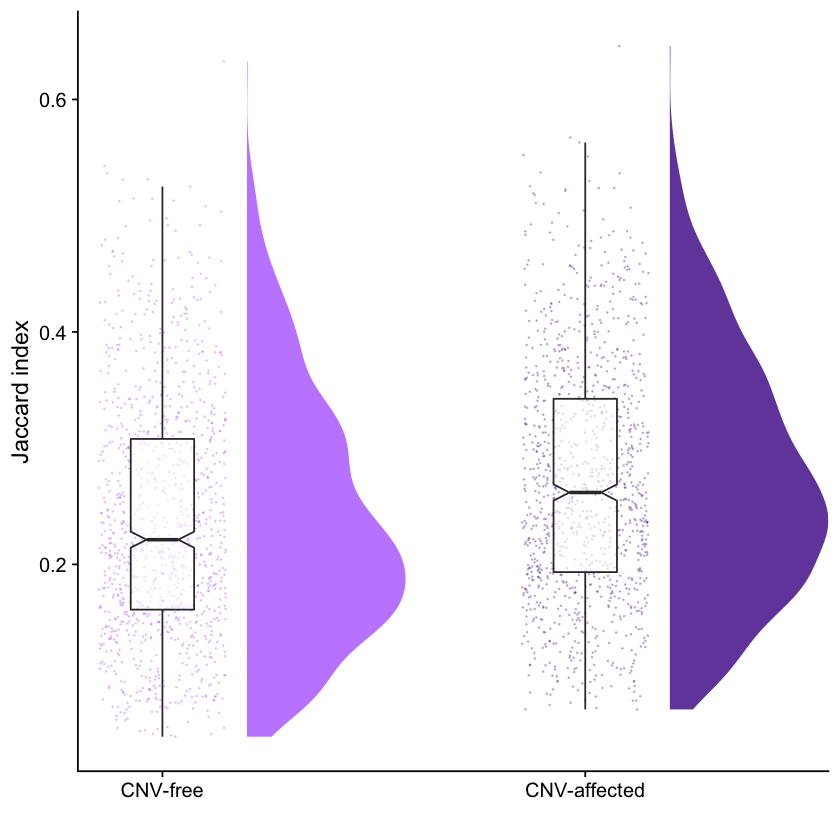

In [47]:
ggplot(mergedForPlotOfJaccardIndex, aes(ZarreiCNV, value)) +
    theme_cowplot() +
    geom_flat_violin(aes(fill = ZarreiCNV), position = position_nudge(x = .2, y = 0), alpha = .8, scale="width", width=0.75, color=NA) +
    geom_point(aes(color = ZarreiCNV), position = position_jitter(width = .15), size = .075, alpha = 0.25) +
    geom_boxplot(notch=TRUE, width = .15, outlier.shape = NA, alpha = 0.6) +
    scale_y_continuous(name="Jaccard index") +
    scale_x_discrete(name="",
        breaks=c("N", "Y"),
        labels=c("CNV-free", "CNV-affected"),
        expand=c(.1,.1)) +
    scale_color_manual(values=c("#b66dff", "#490092"),
        name="",
        breaks=c("N", "Y"),
        labels=c("CNV-free", "CNV-affected")) +
    scale_fill_manual(values=c("#b66dff", "#490092"),
        name="",
        breaks=c("N", "Y"),
        labels=c("CNV-free", "CNV-affected")) +
    theme(legend.position="none")

In [20]:
ggsave("../../outputFiles/figures/eQTLJaccardIndexBonferroniExACCNVRaincloudPlot.svg", plot = last_plot(), width=8, height=10, units="cm")

In [48]:
colnames(melted_jaccardY) <- c("Var2","Var1","value","ZarreiCNV")
neccessaryForOrder1<-data.frame("Adipose - Subcutaneous","Adipose - Subcutaneous",NA,NA)
names(neccessaryForOrder1)<-c("Var1","Var2","value","ZarreiCNV")
melted_jaccard <- rbind(neccessaryForOrder1,na.omit(melted_jaccardY), na.omit(melted_jaccardN))

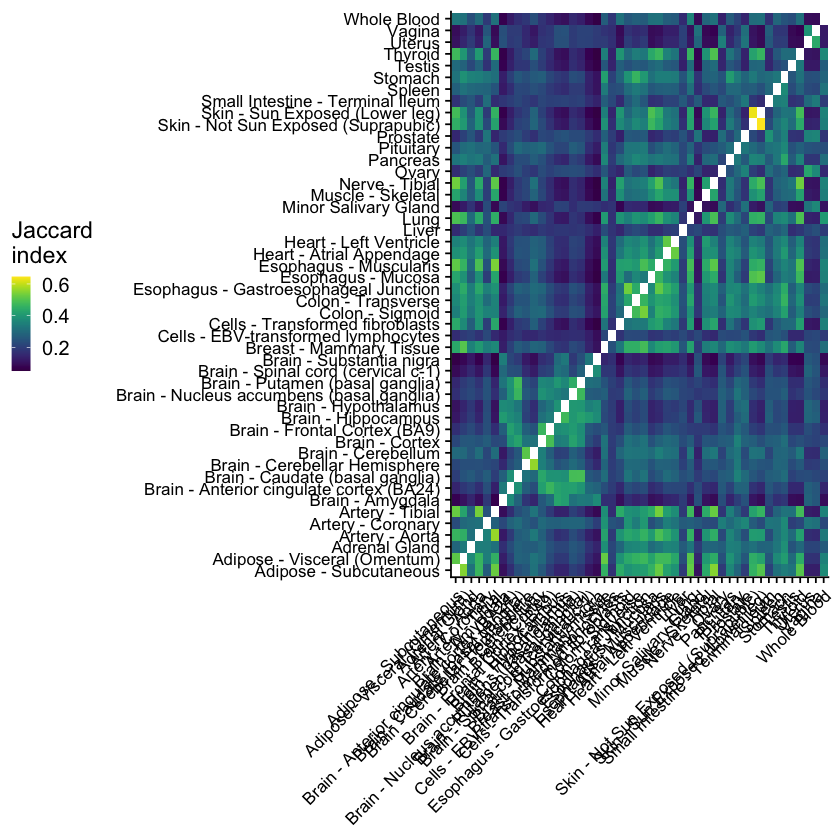

In [49]:
ggplot(data = na.omit(melted_jaccard), aes(x=Var1, y=Var2, fill=value)) + 
    geom_tile() +
    theme_cowplot() +
    scale_fill_viridis("Jaccard\nindex", na.value = 'white',direction = 1) +
    theme(legend.key.size= unit(0.4, "cm"),
          legend.position="left",
          legend.direction = "vertical",
          axis.text.x=element_text(angle = 45, vjust = 1, hjust=1, size = rel(0.85)),
          #axis.text.x=element_blank(),
          #axis.ticks.x=element_blank(),
          axis.title.x=element_blank(),
          axis.text.y=element_text(size = rel(0.85)),
          axis.title.y=element_blank()) +
    scale_y_discrete(limits = rev(levels(melted_jaccard$Var2)))

In [28]:
ggsave('../../outputFiles/figures/eQTLJaccardIndexBonferroniOhnologHeatmap.svg', plot = last_plot(), width = 27, height = 19, units = c("cm"))

---

### Proportion of genes affected by eQTLs per tissue
[Back to top](#Outline)

In [50]:
tissue_list <- c() 
eqtl_list <- c()
ZarreiCNV_list <- c()
count_list <- c()

for (tissue in c('Adipose - Subcutaneous',
                'Adipose - Visceral (Omentum)',
                'Adrenal Gland',
                'Artery - Aorta',
                'Artery - Coronary',
                'Artery - Tibial',
                'Brain - Amygdala',
                'Brain - Anterior cingulate cortex (BA24)',
                'Brain - Caudate (basal ganglia)',
                'Brain - Cerebellar Hemisphere',
                'Brain - Cerebellum',
                'Brain - Cortex',
                'Brain - Frontal Cortex (BA9)',
                'Brain - Hippocampus',
                'Brain - Hypothalamus',
                'Brain - Nucleus accumbens (basal ganglia)',
                'Brain - Putamen (basal ganglia)',
                'Brain - Spinal cord (cervical c-1)',
                'Brain - Substantia nigra',
                'Breast - Mammary Tissue',
                'Cells - EBV-transformed lymphocytes',
                'Cells - Transformed fibroblasts',
                'Colon - Sigmoid',
                'Colon - Transverse',
                'Esophagus - Gastroesophageal Junction',
                'Esophagus - Mucosa',
                'Esophagus - Muscularis',
                'Heart - Atrial Appendage',
                'Heart - Left Ventricle',
                'Liver',
                'Lung',
                'Minor Salivary Gland',
                'Muscle - Skeletal',
                'Nerve - Tibial',
                'Ovary',
                'Pancreas',
                'Pituitary',
                'Prostate',
                'Skin - Not Sun Exposed (Suprapubic)',
                'Skin - Sun Exposed (Lower leg)',
                'Small Intestine - Terminal Ileum',
                'Spleen',
                'Stomach',
                'Testis',
                'Thyroid',
                'Uterus',
                'Vagina',
                'Whole Blood')){
    
    for (option1 in c('Y',
                'N')){
        
        for (option2 in c('Y',
                'N')){
    
            tissue_list <- c(tissue_list, tissue)
            ZarreiCNV_list <- c(ZarreiCNV_list, option1)
            eqtl_list <- c(eqtl_list, option2)
            count_list <- c(count_list, nrow(subset(tested[[tissue]], ZarreiCNV == option1 & eQTL == option2, select=c(Ensembl.Gene.ID))))
        }
    }
}

In [51]:
eQTLZarreiCNVCountPerTissue <- data.frame(tissue_list,
                                        ZarreiCNV_list,
                                        eqtl_list,
                                        count_list)
names(eQTLZarreiCNVCountPerTissue) <- c('tissue',
                                      'ZarreiCNV',
                                      'eqtl',
                                      'count')
eQTLZarreiCNVCountPerTissue

tissue,ZarreiCNV,eqtl,count
<chr>,<chr>,<chr>,<int>
Adipose - Subcutaneous,Y,Y,2394
Adipose - Subcutaneous,Y,N,3784
Adipose - Subcutaneous,N,Y,3401
Adipose - Subcutaneous,N,N,6846
Adipose - Visceral (Omentum),Y,Y,1722
Adipose - Visceral (Omentum),Y,N,4486
Adipose - Visceral (Omentum),N,Y,2289
Adipose - Visceral (Omentum),N,N,8015
Adrenal Gland,Y,Y,1149


In [53]:
dcast(eQTLZarreiCNVCountPerTissue, tissue + eqtl ~ ZarreiCNV)

Using count as value column: use value.var to override.



tissue,eqtl,N,Y
<chr>,<chr>,<int>,<int>
Adipose - Subcutaneous,N,6846,3784
Adipose - Subcutaneous,Y,3401,2394
Adipose - Visceral (Omentum),N,8015,4486
Adipose - Visceral (Omentum),Y,2289,1722
Adrenal Gland,N,8650,4965
Adrenal Gland,Y,1472,1149
Artery - Aorta,N,7583,4227
Artery - Aorta,Y,2561,1863
Artery - Coronary,N,9358,5431


In [54]:
dcast(eQTLZarreiCNVCountPerTissue, tissue ~ eqtl + ZarreiCNV)

Using count as value column: use value.var to override.



tissue,N_N,N_Y,Y_N,Y_Y
<chr>,<int>,<int>,<int>,<int>
Adipose - Subcutaneous,6846,3784,3401,2394
Adipose - Visceral (Omentum),8015,4486,2289,1722
Adrenal Gland,8650,4965,1472,1149
Artery - Aorta,7583,4227,2561,1863
Artery - Coronary,9358,5431,924,742
Artery - Tibial,6447,3529,3561,2516
Brain - Amygdala,9957,5949,342,299
Brain - Anterior cingulate cortex (BA24),9617,5700,705,546
Brain - Caudate (basal ganglia),9312,5398,1037,865


In [55]:
eQTLZarreiCNVCountPerTissueWide <- dcast(eQTLZarreiCNVCountPerTissue, tissue + eqtl ~ ZarreiCNV)
rownames(eQTLZarreiCNVCountPerTissueWide) <- paste(eQTLZarreiCNVCountPerTissueWide[,1],eQTLZarreiCNVCountPerTissueWide[,2])
eQTLZarreiCNVCountPerTissueWide[,1] <- NULL
eQTLZarreiCNVCountPerTissueWide[,1] <- NULL
eQTLZarreiCNVCountPerTissueWide

Using count as value column: use value.var to override.



,N,Y
,<int>,<int>
Adipose - Subcutaneous N,6846,3784
Adipose - Subcutaneous Y,3401,2394
Adipose - Visceral (Omentum) N,8015,4486
Adipose - Visceral (Omentum) Y,2289,1722
Adrenal Gland N,8650,4965
Adrenal Gland Y,1472,1149
Artery - Aorta N,7583,4227
Artery - Aorta Y,2561,1863
Artery - Coronary N,9358,5431


In [56]:
Xsq<- chisq.test(eQTLZarreiCNVCountPerTissueWide)
Xsq
Xsq$stdres     # standardized residuals


	Pearson's Chi-squared test

data:  eQTLZarreiCNVCountPerTissueWide
X-squared = 2265, df = 95, p-value < 2.2e-16


,N,Y
Adipose - Subcutaneous N,4.2371536,-4.2371536
Adipose - Subcutaneous Y,-5.8957729,5.8957729
Adipose - Visceral (Omentum) N,3.9308223,-3.9308223
Adipose - Visceral (Omentum) Y,-7.0238795,7.0238795
Adrenal Gland N,2.6907418,-2.6907418
Adrenal Gland Y,-6.6324544,6.6324544
Artery - Aorta N,4.0301655,-4.0301655
Artery - Aorta Y,-6.2482632,6.2482632
Artery - Coronary N,2.1572892,-2.1572892
Artery - Coronary Y,-5.8748500,5.8748500


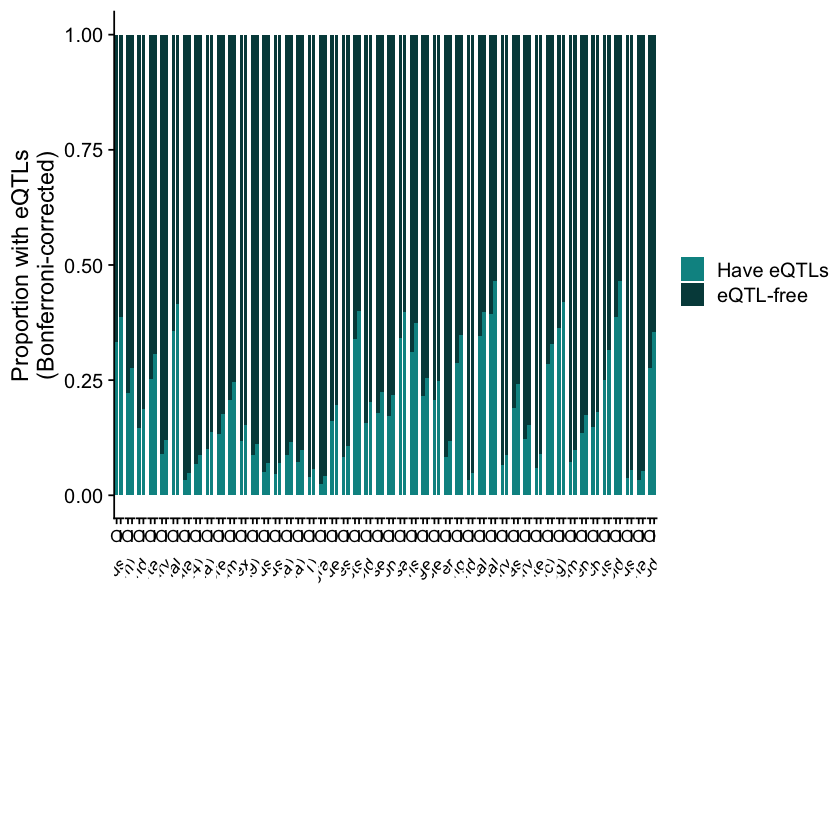

In [63]:
ggplot(eQTLZarreiCNVCountPerTissue, aes(x=ZarreiCNV, y=count, fill=factor(eqtl))) +
    theme_cowplot() +
    geom_bar(stat="identity", position="fill") +
    facet_wrap(~tissue, strip.position = "bottom", scales="free_x", nrow=1) +
    theme(strip.placement = "outside", panel.spacing = unit(0.1, 'lines'), strip.background = element_blank(), strip.text.x = element_text(angle = 45, vjust = 1, hjust=1, size = rel(0.85)), axis.text.x = element_text(size = rel(0.85))) +
    scale_y_continuous(name="Proportion with eQTLs\n(Bonferroni-corrected)") +
    scale_x_discrete(name="",
        breaks=c("Y", "N"),
        labels=c("I", "O")) +
    scale_fill_manual(values=c("#009292", "#004949"),
        name="",
        breaks=c("Y", "N"),
        labels=c("Have eQTLs", "eQTL-free"))


In [64]:
ggsave('../../outputFiles/figures/eQTLZarreiCNVCountPerTissueBonferroni.svg', plot = last_plot(), width = 30, height = 15.5, units = c("cm"))